In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

# Validate Sampling: Law of Large Numbers

We demonstrate that the **sample average converges to the true distribution mean** as the number of samples increases.

Given a distribution $p(x)$ and a function $f(x)$, the true expectation is:
$$E[f(X)] = \int f(x)\, p(x)\, dx$$

The Monte Carlo estimate with $N$ samples is:
$$\hat{\mu}_N = \frac{1}{N} \sum_{i=1}^{N} f(x_i), \quad x_i \sim p(x)$$

By the **Law of Large Numbers**, $\hat{\mu}_N \to E[f(X)]$ as $N \to \infty$.

## Example 1: Normal Distribution — Estimate $E[X^2]$

Let $X \sim \mathcal{N}(\mu, \sigma^2)$. We estimate $E[X^2]$.

Analytically: $E[X^2] = \mu^2 + \sigma^2$

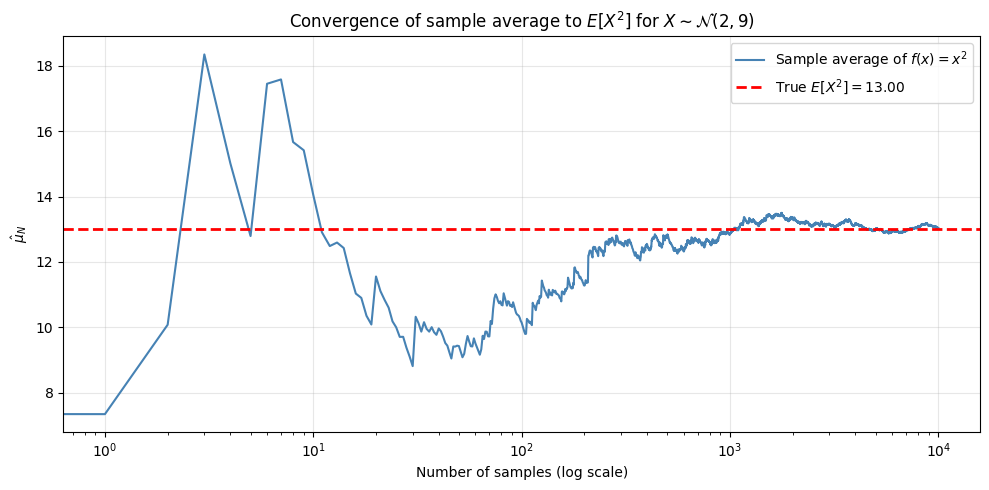

True E[X^2]      = 13.0000
Estimate (N=10000) = 13.0359
Absolute error   = 0.0359


In [12]:
np.random.seed(42)

mu, sigma = 2.0, 3.0  # mean and standard deviation of the normal distribution
f = lambda x: x ** 2                       # function whose expectation we estimate
true_expectation = mu**2 + sigma**2         # E[X^2] = mu^2 + sigma^2

max_samples = 10_000
samples = np.random.normal(mu, sigma, size=max_samples)
cumulative_avg = np.cumsum(f(samples)) / np.arange(1, max_samples + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_avg, label=r"Sample average of $f(x) = x^2$", color="steelblue")
plt.axhline(y=true_expectation, color="red", linestyle="--", linewidth=2,
            label=f"True $E[X^2] = {true_expectation:.2f}$")
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel(r"$\hat{\mu}_N$")
plt.title(r"Convergence of sample average to $E[X^2]$ for $X \sim \mathcal{N}(2, 9)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/ex1_normal_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"True E[X^2]      = {true_expectation:.4f}")
print(f"Estimate (N={max_samples}) = {cumulative_avg[-1]:.4f}")
print(f"Absolute error   = {abs(cumulative_avg[-1] - true_expectation):.4f}")

## Example 2: Exponential Distribution — Estimate $E[\sin(X)]$

Let $X \sim \text{Exp}(\lambda)$. We estimate $E[\sin(X)]$.

Analytically: $E[\sin(X)] = \frac{\lambda}{\lambda^2 + 1}$

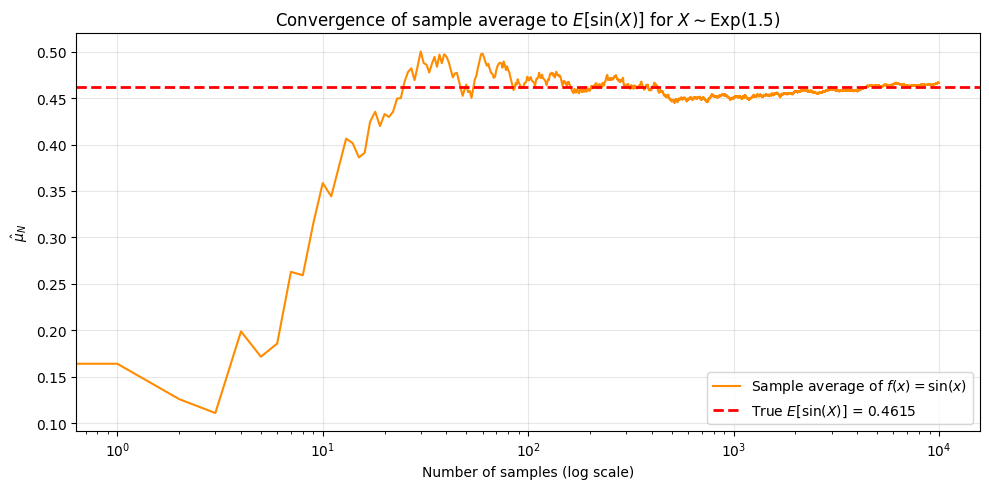

True E[sin(X)]   = 0.4615
Estimate (N=10000) = 0.4663
Absolute error   = 0.0047


In [13]:
lam = 1.5
f2 = np.sin
true_exp2 = lam / (lam**2 + 1)             # closed-form for E[sin(X)]

samples2 = np.random.exponential(1 / lam, size=max_samples)
cumulative_avg2 = np.cumsum(f2(samples2)) / np.arange(1, max_samples + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_avg2, label=r"Sample average of $f(x) = \sin(x)$", color="darkorange")
plt.axhline(y=true_exp2, color="red", linestyle="--", linewidth=2,
            label=f"True $E[\\sin(X)]$ = {true_exp2:.4f}")
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel(r"$\hat{\mu}_N$")
plt.title(r"Convergence of sample average to $E[\sin(X)]$ for $X \sim \mathrm{Exp}(1.5)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/ex2_exponential_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"True E[sin(X)]   = {true_exp2:.4f}")
print(f"Estimate (N={max_samples}) = {cumulative_avg2[-1]:.4f}")
print(f"Absolute error   = {abs(cumulative_avg2[-1] - true_exp2):.4f}")

## Example 3: Multiple Trials — Confidence Envelope

Run multiple independent trials to show the **convergence spread** and standard error shrinking as $O(1/\sqrt{N})$.

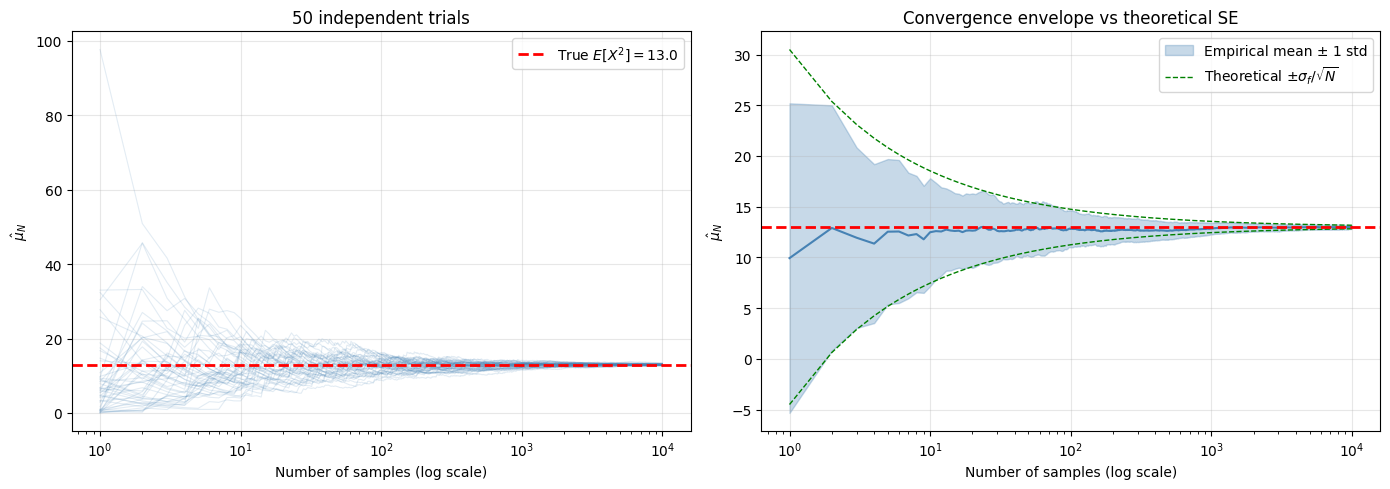

In [14]:
n_trials = 50
mu, sigma = 2.0, 3.0
f = lambda x: x ** 2
true_expectation = mu**2 + sigma**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: multiple trial trajectories ---
all_trajectories = np.zeros((n_trials, max_samples))
for t in range(n_trials):
    s = np.random.normal(mu, sigma, size=max_samples)
    all_trajectories[t] = np.cumsum(f(s)) / np.arange(1, max_samples + 1)

ns = np.arange(1, max_samples + 1)
for t in range(n_trials):
    axes[0].plot(ns, all_trajectories[t], alpha=0.15, color="steelblue", linewidth=0.8)
axes[0].axhline(y=true_expectation, color="red", linestyle="--", linewidth=2, label=f"True $E[X^2]={true_expectation:.1f}$")
axes[0].set_xscale("log")
axes[0].set_xlabel("Number of samples (log scale)")
axes[0].set_ylabel(r"$\hat{\mu}_N$")
axes[0].set_title(f"{n_trials} independent trials")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right: mean ± std across trials vs theoretical SE ---
mean_traj = all_trajectories.mean(axis=0)
std_traj = all_trajectories.std(axis=0)

# Theoretical standard error: sigma_f / sqrt(N), where sigma_f^2 = Var[f(X)] = E[X^4] - (E[X^2])^2
# For X~N(mu,sigma^2): E[X^4] = mu^4 + 6*mu^2*sigma^2 + 3*sigma^4
EX4 = mu**4 + 6*mu**2*sigma**2 + 3*sigma**4
var_f = EX4 - true_expectation**2
theoretical_se = np.sqrt(var_f / ns)

axes[1].fill_between(ns, mean_traj - std_traj, mean_traj + std_traj,
                     alpha=0.3, color="steelblue", label="Empirical mean ± 1 std")
axes[1].plot(ns, mean_traj, color="steelblue", linewidth=1.5)
axes[1].plot(ns, true_expectation + theoretical_se, "g--", linewidth=1, label=r"Theoretical $\pm \sigma_f / \sqrt{N}$")
axes[1].plot(ns, true_expectation - theoretical_se, "g--", linewidth=1)
axes[1].axhline(y=true_expectation, color="red", linestyle="--", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of samples (log scale)")
axes[1].set_ylabel(r"$\hat{\mu}_N$")
axes[1].set_title("Convergence envelope vs theoretical SE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images/ex3_confidence_envelope.png", dpi=150, bbox_inches="tight")
plt.show()

## Example 4: Discrete Distribution — Estimate $E[f(X)]$ for a custom PMF

Define a discrete random variable $X$ with known PMF and verify convergence for $f(x) = x^2$.

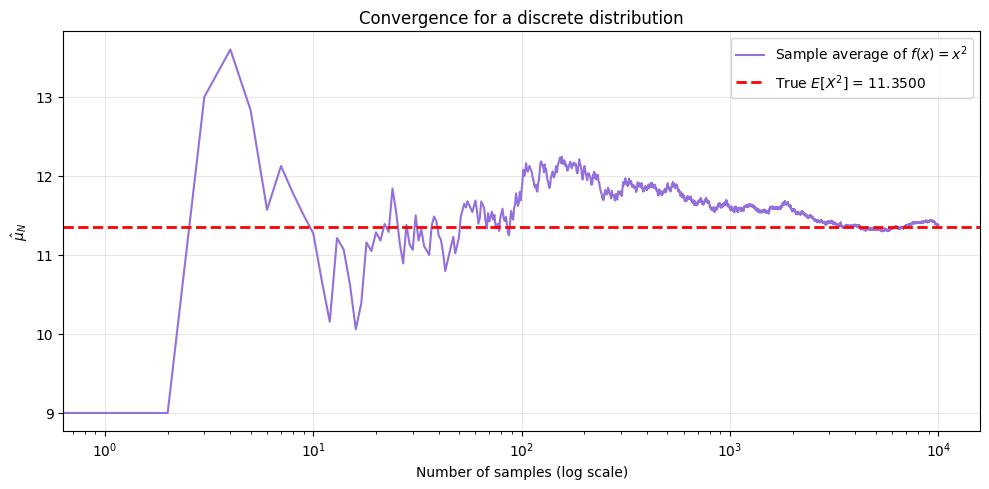

PMF:  values = [1 2 3 4 5],  probs = [0.1  0.2  0.3  0.25 0.15]
True E[X^2]      = 11.3500
Estimate (N=10000) = 11.3819
Absolute error   = 0.0319


In [15]:
# Discrete distribution: X ∈ {1, 2, 3, 4, 5} with given probabilities
values = np.array([1, 2, 3, 4, 5])
probs  = np.array([0.1, 0.2, 0.3, 0.25, 0.15])

f_disc = lambda x: x ** 2
true_exp_disc = np.sum(f_disc(values) * probs)    # E[f(X)] = sum f(x)*p(x)

samples_disc = np.random.choice(values, size=max_samples, p=probs)
cumulative_avg_disc = np.cumsum(f_disc(samples_disc)) / np.arange(1, max_samples + 1)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_avg_disc, label=r"Sample average of $f(x)=x^2$", color="mediumpurple")
plt.axhline(y=true_exp_disc, color="red", linestyle="--", linewidth=2,
            label=f"True $E[X^2]$ = {true_exp_disc:.4f}")
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel(r"$\hat{\mu}_N$")
plt.title("Convergence for a discrete distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/ex4_discrete_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PMF:  values = {values},  probs = {probs}")
print(f"True E[X^2]      = {true_exp_disc:.4f}")
print(f"Estimate (N={max_samples}) = {cumulative_avg_disc[-1]:.4f}")
print(f"Absolute error   = {abs(cumulative_avg_disc[-1] - true_exp_disc):.4f}")